<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/asif/Food_expiry_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# STEP 1 : Import Libraries
# ================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# ================================
# STEP 2 : Load Dataset
# ================================

df = pd.read_csv("food_expiry_tracker.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
# ================================
# STEP 3 : Dataset Overview
# ================================

print("Shape of Dataset")
print(df.shape)

print("\n")

print("First Five Rows")
display(df.head())

print("\n")

print("Column Names")
print(df.columns.tolist())

Shape of Dataset
(500, 15)


First Five Rows


,purchase_month,purchase_day_of_week,days_until_expiry,quantity,used_before_expiry,item_beverage,item_dairy,item_fruit,item_grain,item_meat,item_snack,item_vegetable,storage_freezer,storage_fridge,storage_pantry
0,0.000000,0.000000,0.041322,0.555556,1,False,False,False,False,False,False,True,False,True,False
1,0.636364,0.166667,0.209366,0.555556,1,False,False,False,True,False,False,False,True,False,False
2,0.181818,0.000000,0.595041,0.333333,1,True,False,False,False,False,False,False,False,True,False
3,0.181818,0.500000,0.022039,0.555556,1,False,True,False,False,False,False,False,False,True,False
4,0.818182,0.666667,0.526171,1.000000,1,False,False,False,False,False,True,False,True,False,False




Column Names
['purchase_month', 'purchase_day_of_week', 'days_until_expiry', 'quantity', 'used_before_expiry', 'item_beverage', 'item_dairy', 'item_fruit', 'item_grain', 'item_meat', 'item_snack', 'item_vegetable', 'storage_freezer', 'storage_fridge', 'storage_pantry']


In [ ]:
# ================================
# STEP 4 : Dataset Information
# ================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_month        500 non-null    float64
 1   purchase_day_of_week  500 non-null    float64
 2   days_until_expiry     500 non-null    float64
 3   quantity              500 non-null    float64
 4   used_before_expiry    500 non-null    int64  
 5   item_beverage         500 non-null    bool   
 6   item_dairy            500 non-null    bool   
 7   item_fruit            500 non-null    bool   
 8   item_grain            500 non-null    bool   
 9   item_meat             500 non-null    bool   
 10  item_snack            500 non-null    bool   
 11  item_vegetable        500 non-null    bool   
 12  storage_freezer       500 non-null    bool   
 13  storage_fridge        500 non-null    bool   
 14  storage_pantry        500 non-null    bool   
dtypes: bool(10), float64(4)

In [ ]:
# ================================
# STEP 5 : Statistical Summary
# ================================

display(df.describe())

,purchase_month,purchase_day_of_week,days_until_expiry,quantity,used_before_expiry
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.481273,0.483000,0.203030,0.498889,0.786000
std,0.304593,0.328437,0.276491,0.322926,0.410538
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.181818,0.166667,0.016529,0.222222,1.000000
50%,0.454545,0.500000,0.037190,0.555556,1.000000
75%,0.727273,0.833333,0.371901,0.777778,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# ================================
# STEP 6 : Missing Values
# ================================

missing = df.isnull().sum()

display(missing)

print("Total Missing Values:", missing.sum())

,0
purchase_month,0
purchase_day_of_week,0
days_until_expiry,0
quantity,0
used_before_expiry,0
item_beverage,0
item_dairy,0
item_fruit,0
item_grain,0
item_meat,0


Total Missing Values: 0


In [ ]:
# ================================
# STEP 7 : Duplicate Rows
# ================================

duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 0


used_before_expiry
1    393
0    107
Name: count, dtype: int64


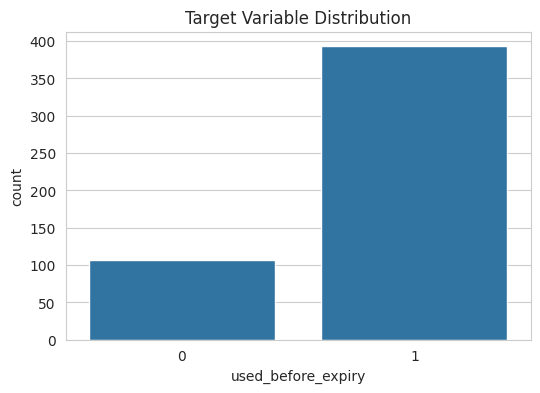

In [ ]:
# ================================
# STEP 8 : Target Distribution
# ================================

print(df["used_before_expiry"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x="used_before_expiry",
    data=df
)

plt.title("Target Variable Distribution")

plt.show()

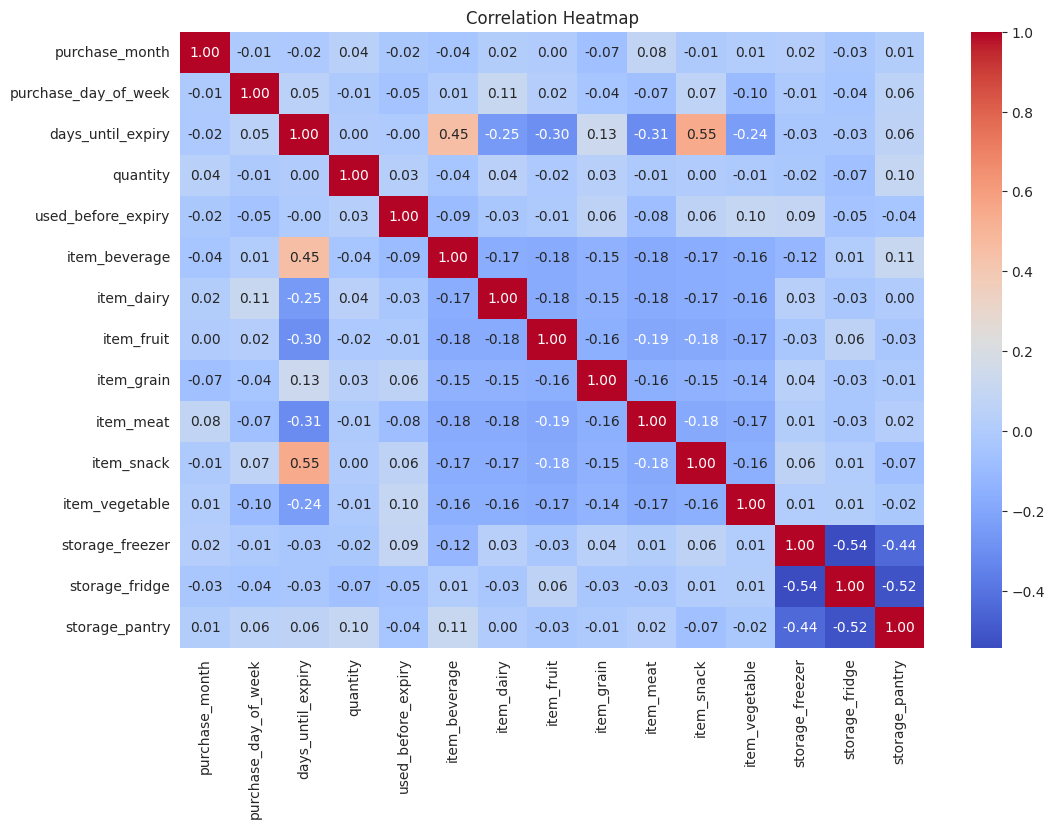

In [ ]:
# ================================
# STEP 9 : Correlation Heatmap
# ================================

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

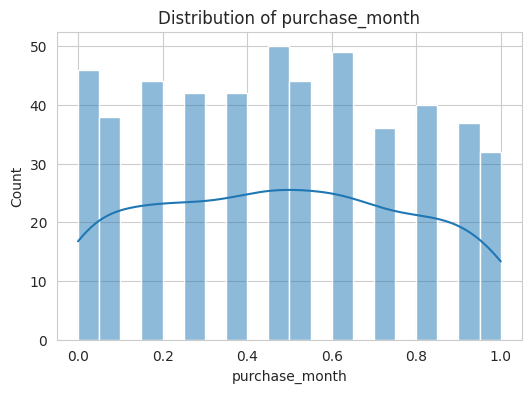

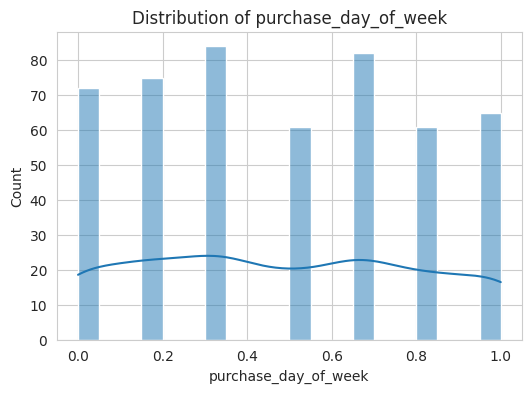

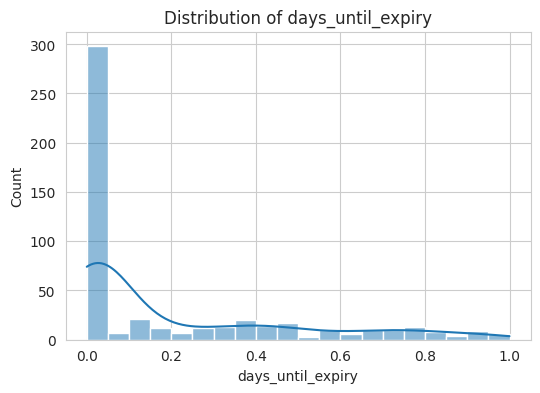

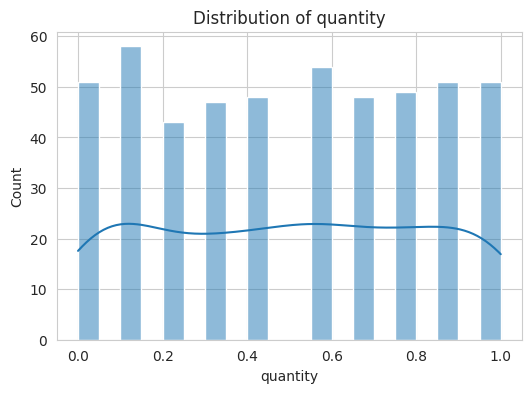

In [ ]:
# ================================
# STEP 10 : Distribution Plots
# ================================

numerical_features = [
    "purchase_month",
    "purchase_day_of_week",
    "days_until_expiry",
    "quantity"
]

for feature in numerical_features:

    plt.figure(figsize=(6,4))

    sns.histplot(df[feature], bins=20, kde=True)

    plt.title(f"Distribution of {feature}")

    plt.show()

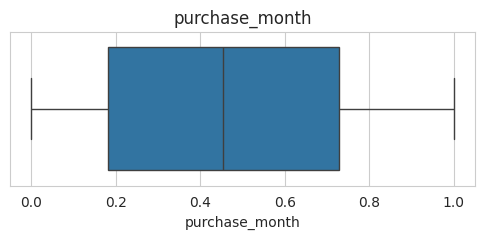

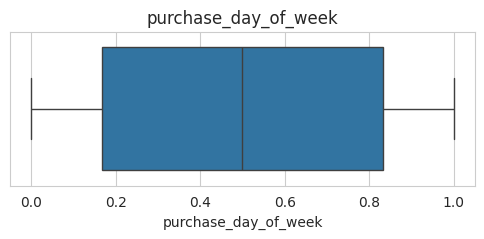

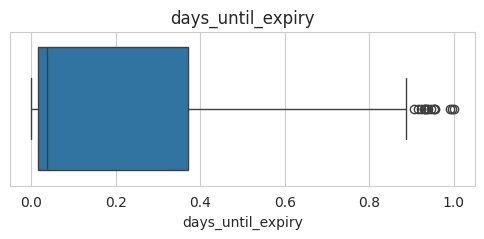

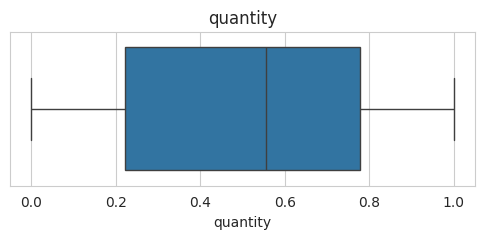

In [ ]:
# ================================
# STEP 11 : Boxplots
# ================================

for feature in numerical_features:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[feature])

    plt.title(feature)

    plt.show()

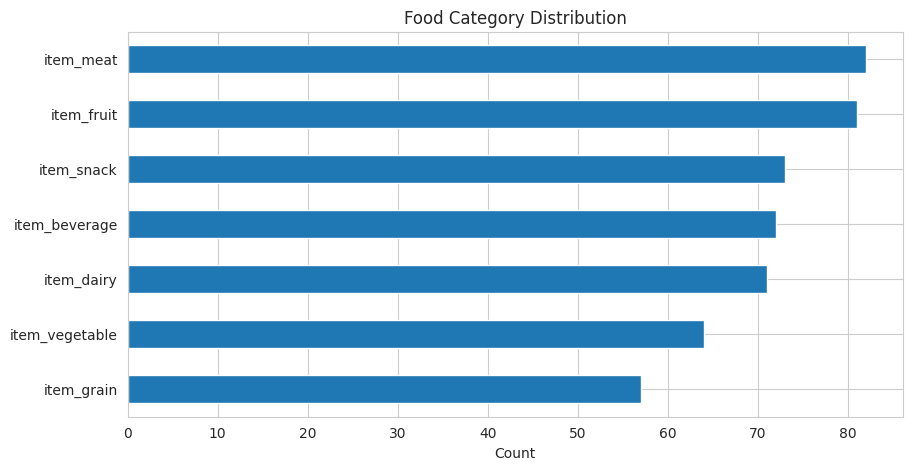

In [ ]:
# ================================
# STEP 12 : Food Category Frequency
# ================================

food_columns = [
    "item_beverage",
    "item_dairy",
    "item_fruit",
    "item_grain",
    "item_meat",
    "item_snack",
    "item_vegetable"
]

food_counts = df[food_columns].sum()

plt.figure(figsize=(10,5))

food_counts.sort_values().plot(kind='barh')

plt.title("Food Category Distribution")

plt.xlabel("Count")

plt.show()

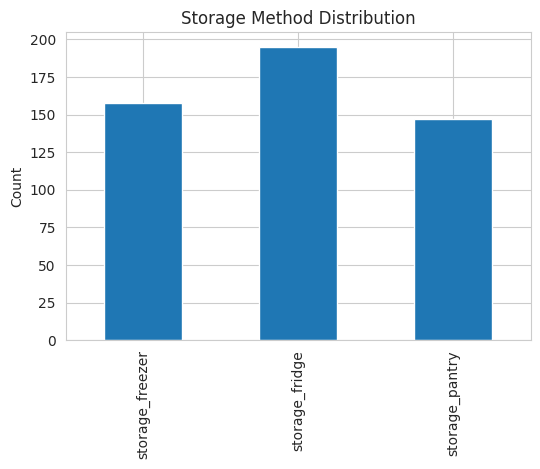

In [ ]:
# ================================
# STEP 13 : Storage Method
# ================================

storage_columns = [
    "storage_freezer",
    "storage_fridge",
    "storage_pantry"
]

storage_counts = df[storage_columns].sum()

plt.figure(figsize=(6,4))

storage_counts.plot(kind="bar")

plt.title("Storage Method Distribution")

plt.ylabel("Count")

plt.show()

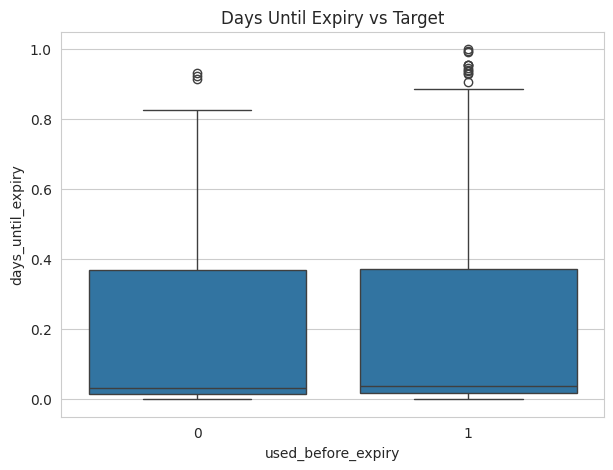

In [ ]:
# ================================
# STEP 14 : Days Until Expiry vs Target
# ================================

plt.figure(figsize=(7,5))

sns.boxplot(
    x="used_before_expiry",
    y="days_until_expiry",
    data=df
)

plt.title("Days Until Expiry vs Target")

plt.show()

In [ ]:
# ================================
# STEP 15 : Feature Engineering
# ================================

def quantity_category(x):

    if x < 0.33:
        return "Small"

    elif x < 0.66:
        return "Medium"

    else:
        return "Large"

df["quantity_category"] = df["quantity"].apply(quantity_category)

df.head()

,purchase_month,purchase_day_of_week,days_until_expiry,quantity,used_before_expiry,item_beverage,item_dairy,item_fruit,item_grain,item_meat,item_snack,item_vegetable,storage_freezer,storage_fridge,storage_pantry,quantity_category
0,0.000000,0.000000,0.041322,0.555556,1,False,False,False,False,False,False,True,False,True,False,Medium
1,0.636364,0.166667,0.209366,0.555556,1,False,False,False,True,False,False,False,True,False,False,Medium
2,0.181818,0.000000,0.595041,0.333333,1,True,False,False,False,False,False,False,False,True,False,Medium
3,0.181818,0.500000,0.022039,0.555556,1,False,True,False,False,False,False,False,False,True,False,Medium
4,0.818182,0.666667,0.526171,1.000000,1,False,False,False,False,False,True,False,True,False,False,Large


In [ ]:
def season(month):

    month = int(month * 12) + 1

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["season"] = df["purchase_month"].apply(season)

df.head()

,purchase_month,purchase_day_of_week,days_until_expiry,quantity,used_before_expiry,item_beverage,item_dairy,item_fruit,item_grain,item_meat,item_snack,item_vegetable,storage_freezer,storage_fridge,storage_pantry,quantity_category,season
0,0.000000,0.000000,0.041322,0.555556,1,False,False,False,False,False,False,True,False,True,False,Medium,Winter
1,0.636364,0.166667,0.209366,0.555556,1,False,False,False,True,False,False,False,True,False,False,Medium,Summer
2,0.181818,0.000000,0.595041,0.333333,1,True,False,False,False,False,False,False,False,True,False,Medium,Spring
3,0.181818,0.500000,0.022039,0.555556,1,False,True,False,False,False,False,False,False,True,False,Medium,Spring
4,0.818182,0.666667,0.526171,1.000000,1,False,False,False,False,False,True,False,True,False,False,Large,Autumn


In [ ]:
print(df.shape)

(500, 17)


In [ ]:
df = pd.get_dummies(
    df,
    columns=["quantity_category","season"],
    drop_first=True
)

print(df.shape)

(500, 20)


In [ ]:
# ================================
# STEP 16 : Features and Target
# ================================

X = df.drop("used_before_expiry", axis=1)

y = df["used_before_expiry"]

print(X.shape)
print(y.shape)

(500, 19)
(500,)


In [ ]:
# ================================
# STEP 17 : Train-Test Split
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(400, 19)
(100, 19)


In [ ]:
# ================================
# STEP 18 : Standardize Numerical Features
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    "purchase_month",
    "purchase_day_of_week",
    "days_until_expiry",
    "quantity"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling Complete")

Scaling Complete


In [ ]:
# ==========================================
# STEP 19 : Model Evaluation Function
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc = roc_auc_score(y_test, predictions)

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc,4))

    print("\nClassification Report\n")
    print(classification_report(y_test,predictions))

    cm = confusion_matrix(y_test,predictions)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot(cmap="Blues")

    plt.title(model_name)

    plt.show()

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

Logistic Regression
Accuracy : 0.58
Precision: 0.8364
Recall   : 0.5823
F1 Score : 0.6866
ROC AUC  : 0.5769

Classification Report

              precision    recall  f1-score   support

           0       0.27      0.57      0.36        21
           1       0.84      0.58      0.69        79

    accuracy                           0.58       100
   macro avg       0.55      0.58      0.53       100
weighted avg       0.72      0.58      0.62       100



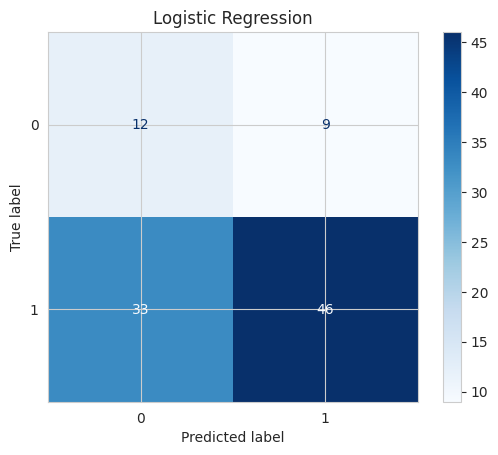

In [ ]:
# ==========================================
# STEP 20 : Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression"
)

Decision Tree
Accuracy : 0.76
Precision: 0.7957
Recall   : 0.9367
F1 Score : 0.8605
ROC AUC  : 0.516

Classification Report

              precision    recall  f1-score   support

           0       0.29      0.10      0.14        21
           1       0.80      0.94      0.86        79

    accuracy                           0.76       100
   macro avg       0.54      0.52      0.50       100
weighted avg       0.69      0.76      0.71       100



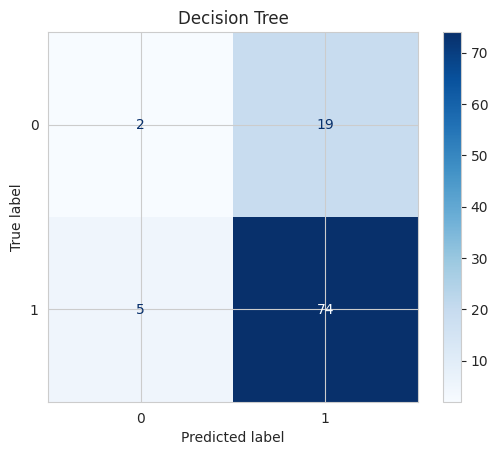

In [ ]:
# ==========================================
# STEP 21 : Decision Tree
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree"
)

Random Forest
Accuracy : 0.78
Precision: 0.7879
Recall   : 0.9873
F1 Score : 0.8764
ROC AUC  : 0.4937

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.79      0.99      0.88        79

    accuracy                           0.78       100
   macro avg       0.39      0.49      0.44       100
weighted avg       0.62      0.78      0.69       100



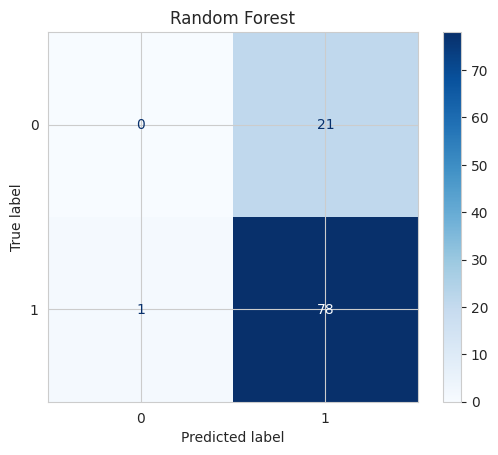

In [ ]:
# ==========================================
# STEP 22 : Random Forest
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

Gradient Boosting
Accuracy : 0.78
Precision: 0.7938
Recall   : 0.9747
F1 Score : 0.875
ROC AUC  : 0.5112

Classification Report

              precision    recall  f1-score   support

           0       0.33      0.05      0.08        21
           1       0.79      0.97      0.88        79

    accuracy                           0.78       100
   macro avg       0.56      0.51      0.48       100
weighted avg       0.70      0.78      0.71       100



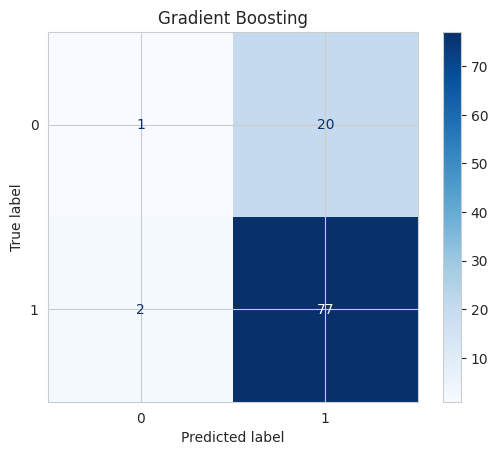

In [ ]:
# ==========================================
# STEP 23 : Gradient Boosting
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test,
    "Gradient Boosting"
)

In [ ]:
# ==========================================
# STEP 24 : Compare Models
# ==========================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

comparison.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.78,0.793814,0.974684,0.875000,0.511151
2,Random Forest,0.78,0.787879,0.987342,0.876404,0.493671
1,Decision Tree,0.76,0.795699,0.936709,0.860465,0.515973
0,Logistic Regression,0.58,0.836364,0.582278,0.686567,0.576854


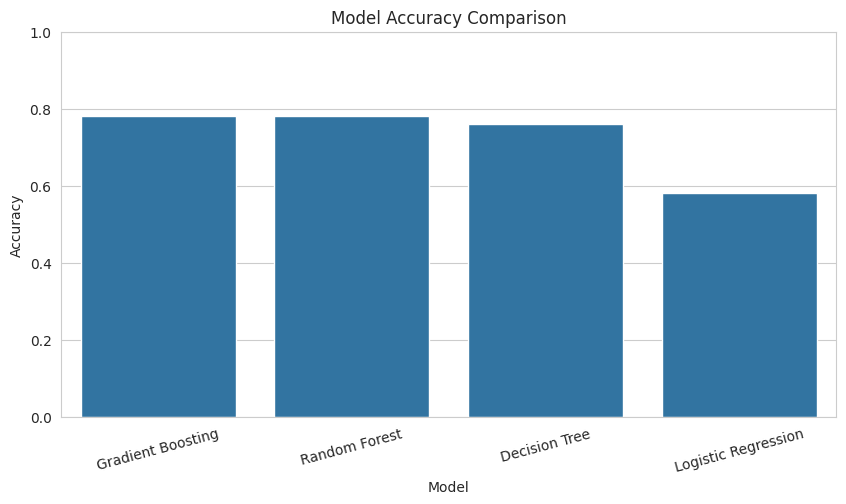

In [ ]:
# ==========================================
# STEP 25 : Accuracy Comparison
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

results=[]

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    model.fit(X_train,y_train)

    predictions=model.predict(X_test)

    probabilities=model.predict_proba(X_test)[:,1]

    accuracy=accuracy_score(y_test,predictions)
    precision=precision_score(y_test,predictions)
    recall=recall_score(y_test,predictions)
    f1=f1_score(y_test,predictions)
    roc=roc_auc_score(y_test,probabilities)

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :",accuracy)
    print("Precision:",precision)
    print("Recall   :",recall)
    print("F1 Score :",f1)
    print("ROC AUC  :",roc)

    print(classification_report(y_test,predictions))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        cmap="Blues"
    )

    plt.show()

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

cv_results=[]

for name,model in models.items():

    if name=="Logistic Regression":

        scores=cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="accuracy"
        )

    else:

        scores=cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="accuracy"
        )

    cv_results.append([

        name,

        scores.mean(),

        scores.std()

    ])

cv_df=pd.DataFrame(

    cv_results,

    columns=[

        "Model",

        "Mean Accuracy",

        "Std"

    ]

)

display(cv_df)

,Model,Mean Accuracy,Std
0,Logistic Regression,0.5425,0.055678
1,Decision Tree,0.7325,0.016956
2,Random Forest,0.7600,0.025495
3,Gradient Boosting,0.7325,0.037583


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid={

    "n_estimators":[100,200,300],

    "max_depth":[3,5,10,None],

    "min_samples_split":[2,5,10]

}

grid=GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
0.7849999999999999


Tuned Random Forest
Accuracy : 0.79
Precision: 0.79
Recall   : 1.0
F1 Score : 0.88268156424581
ROC AUC  : 0.5765521398432791
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.79      1.00      0.88        79

    accuracy                           0.79       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.62      0.79      0.70       100



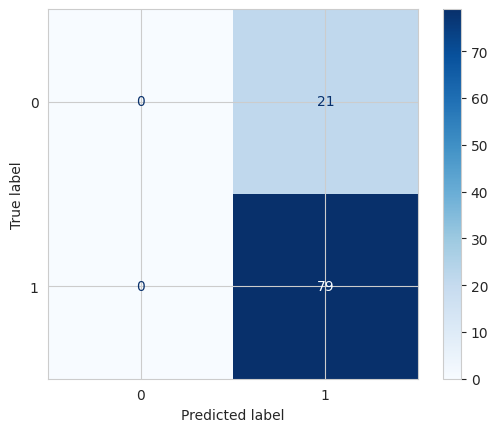

In [ ]:
best_rf=grid.best_estimator_

evaluate_model(

    best_rf,

    X_train,

    X_test,

    y_train,

    y_test,

    "Tuned Random Forest"

)

In [ ]:
feature_importance=pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

feature_importance=feature_importance.sort_values(

    by="Importance",

    ascending=False

)

display(feature_importance)

,Feature,Importance
2,days_until_expiry,0.167350
1,purchase_day_of_week,0.165972
0,purchase_month,0.120536
3,quantity,0.084478
10,item_vegetable,0.078117
11,storage_freezer,0.051429
4,item_beverage,0.043478
5,item_dairy,0.038447
18,season_Winter,0.037102
16,season_Spring,0.034805


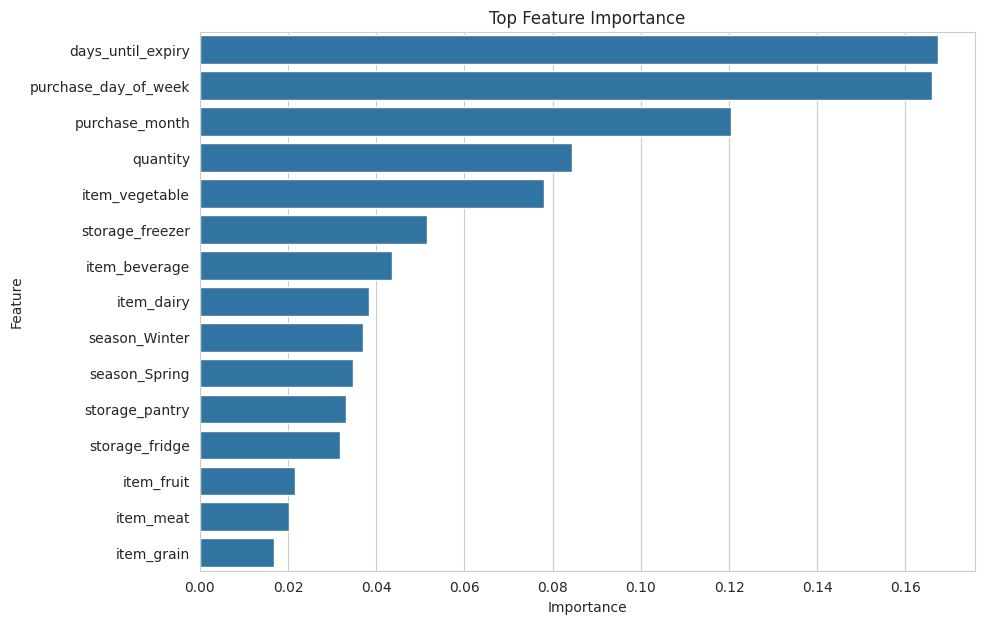

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(

    data=feature_importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top Feature Importance")

plt.show()

In [ ]:
!pip install shap

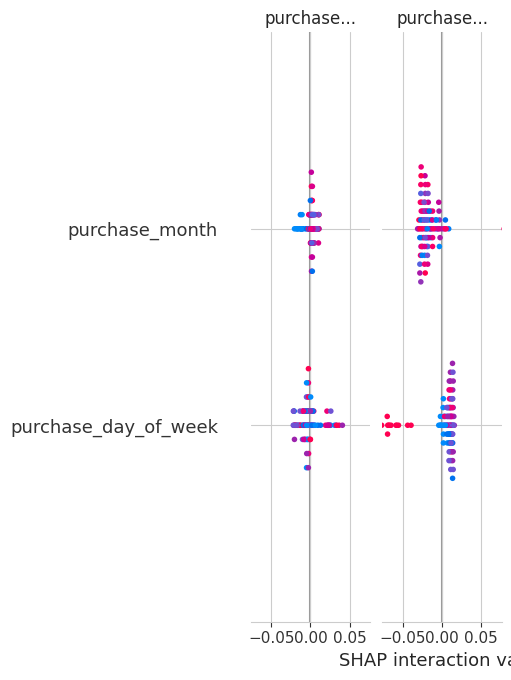

In [ ]:
import shap

explainer=shap.TreeExplainer(best_rf)

shap_values=explainer.shap_values(X_test)

shap.summary_plot(

    shap_values,

    X_test

)

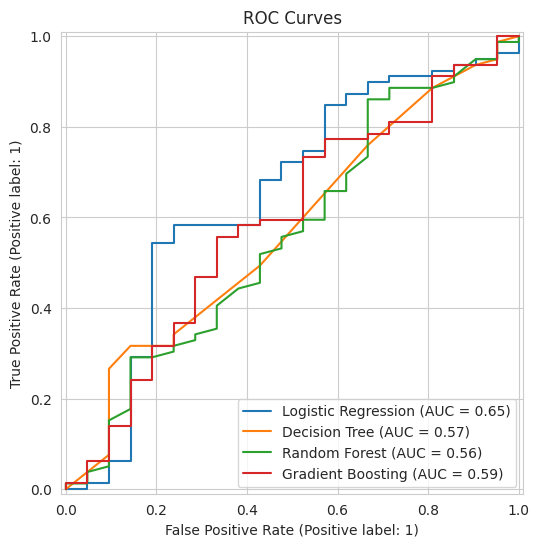

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

models=[

    ("Logistic Regression",lr,X_test_scaled),

    ("Decision Tree",dt,X_test),

    ("Random Forest",rf,X_test),

    ("Gradient Boosting",gb,X_test)

]

for name,model,data in models:

    RocCurveDisplay.from_estimator(

        model,

        data,

        y_test,

        name=name,

        ax=plt.gca()

    )

plt.title("ROC Curves")

plt.show()

In [ ]:
import joblib

joblib.dump(best_rf,"food_waste_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
comparison.sort_values(

    by="F1 Score",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.78,0.787879,0.987342,0.876404,0.493671
3,Gradient Boosting,0.78,0.793814,0.974684,0.875000,0.511151
1,Decision Tree,0.76,0.795699,0.936709,0.860465,0.515973
0,Logistic Regression,0.58,0.836364,0.582278,0.686567,0.576854
